# Bayesian workflow: market returns

SPMO · VOO · 256 trading days

In [1]:
from datetime import datetime
from pathlib import Path

import bayesflow as bf
import keras

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import univariate as model, decisions
from mmar.viz import univariate as plots

SEED = 20260905
TICKERS = ("SPMO", "VOO")
PRIOR = model.PRIOR
FIGURES_DIR = Path("figures/univariate")
CHECKPOINT_DIR = Path("checkpoints/univariate") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")

keras.utils.set_random_seed(SEED)
viz.configure_plot_style()

INFO:bayesflow:Using backend 'torch'


When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## 1. Model specification

$$r_t = \mu + \bar\sigma\sqrt{\theta_t(q)}\,z_t,
\qquad z_t\sim t_\nu\sqrt{(\nu-2)/\nu}.$$

Four fixed parameters; eight 32-day volatility blocks with random circular phase.
Shocks are independent conditional on the cascade, but returns are not marginally IID.
Whole paths crossing −100% are redrawn; shocks are never empirically centered or rescaled.

In [2]:
model.prior_table(PRIOR)

,prior,meaning
parameter,,
mu,"Normal(0, 0.0015²)",Daily drift
sigma_bar,"Uniform(0.005, 0.025)",RMS scale before path rejection
q,"Uniform(0.52, 0.9)",Cascade asymmetry
nu,"2 + exp(Uniform(log(0.05), log(10)))",Student-t degrees of freedom


In [3]:
observed_returns = load_market_returns(TICKERS)
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

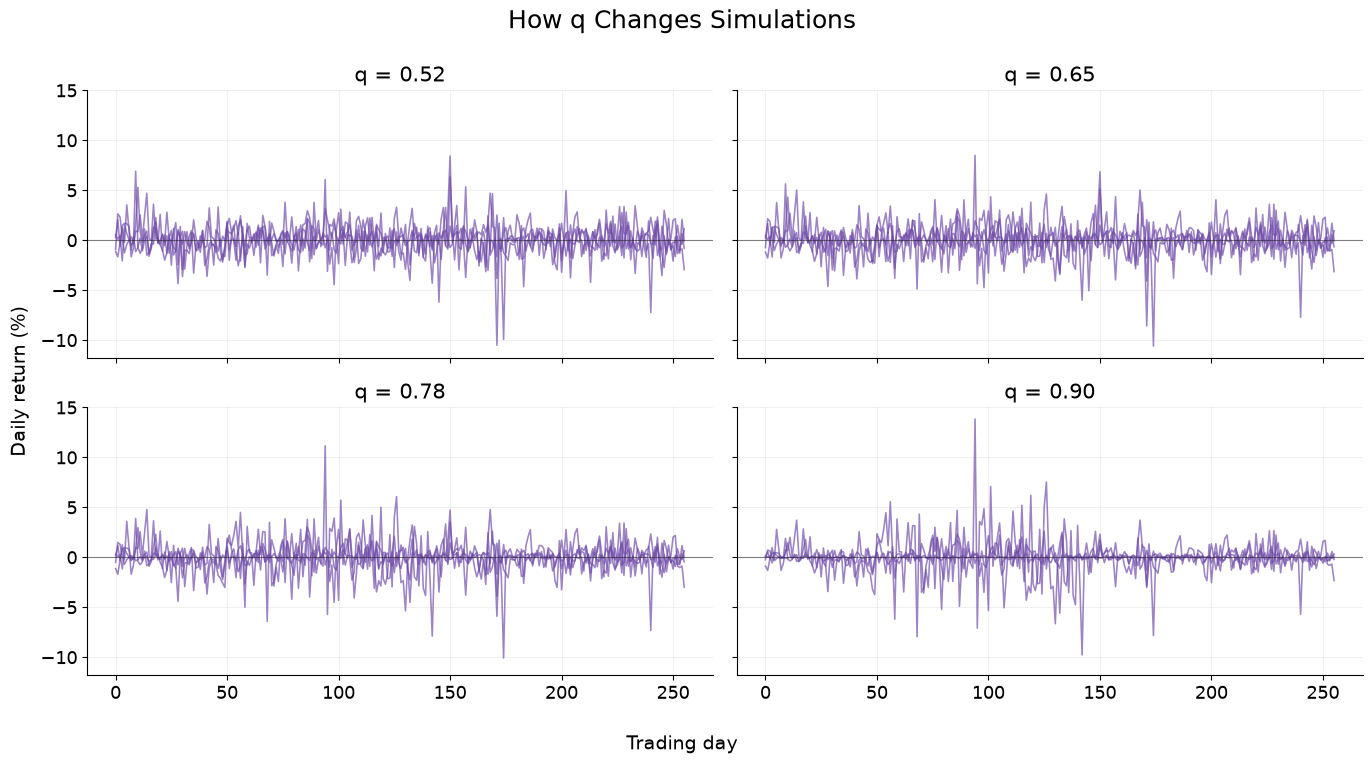

In [4]:
prior_data = model.simulate(3_000, seed=SEED + 20, prior=PRIOR)
prior_returns = prior_data["returns"]

fig = plots.plot_q_turbulence(model.q_scenarios((0.52, 0.65, 0.78, 0.90), seed=SEED + 1))
_ = viz.save_figure(fig, "01_prior_q_turbulence.png", FIGURES_DIR)

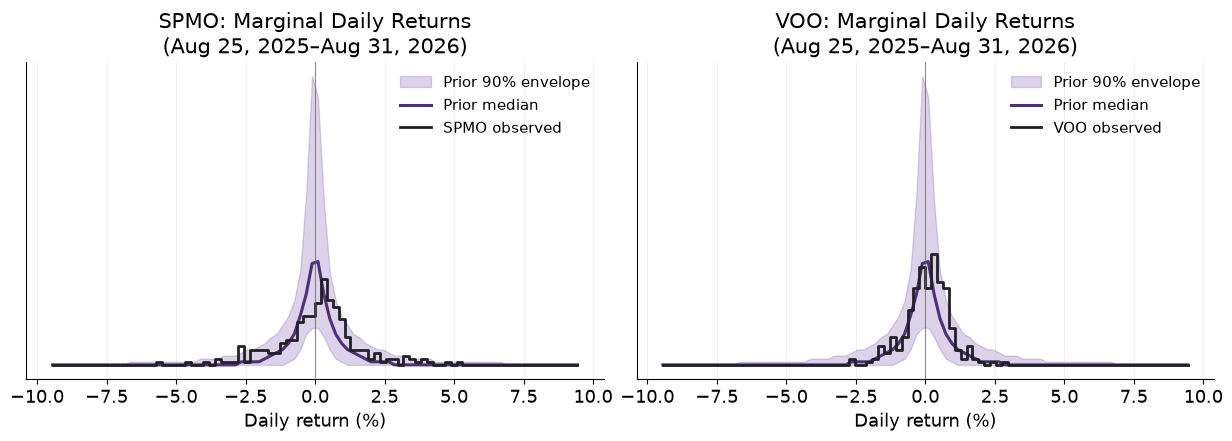

In [5]:
fig = plots.plot_marginal_return_histograms(100 * prior_returns, 100 * observed_window, tickers=TICKERS)
_ = viz.save_figure(fig, "02_prior_marginal_returns.png", FIGURES_DIR)

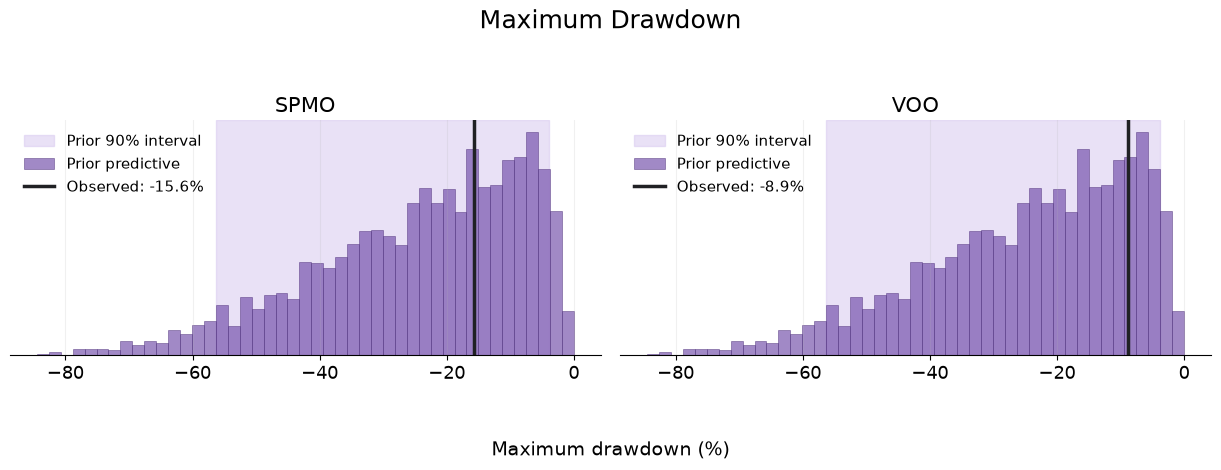

In [6]:
prior_stats = stats.statistics(prior_returns)
observed_stats = stats.statistics(observed_window.to_numpy().T)
observed_stats.index = TICKERS

fig = plots.plot_max_drawdown_checks(prior_stats, observed_stats, tickers=TICKERS)
_ = viz.save_figure(fig, "03_prior_max_drawdown.png", FIGURES_DIR)

In [7]:
envelope = stats.pushforward_envelope_table(prior_stats, observed_stats).rename(
    columns={"observed_pct": "observed", "prior_q05_pct": "prior_q05", "prior_q95_pct": "prior_q95"})
envelope.style.format(precision=2)

,ticker,stat,observed,prior_q05,prior_q95,inside_prior_90pct_band
0,SPMO,mean_pct,0.11,-0.29,0.28,True
1,SPMO,volatility_pct,1.52,0.41,2.38,True
2,SPMO,avg_abs_return_pct,1.10,0.26,1.53,True
3,SPMO,q01_pct,-3.63,-6.68,-1.00,True
4,SPMO,q05_pct,-2.60,-3.39,-0.47,True
5,SPMO,q95_pct,2.72,0.44,3.38,True
6,SPMO,q99_pct,4.02,1.03,6.57,True
7,SPMO,es05_pct,-3.35,-5.57,-0.89,True
8,SPMO,max_drawdown_pct,-15.64,-56.36,-3.84,True
9,SPMO,terminal_wealth,1.27,0.46,2.00,True


## 3. Amortized inference

Constraints are inverted by the adapter: all posterior draws are in original units.
$\mu$ stays unbounded. Normalized returns retain their observed location and scale as conditions.

In [ ]:
adapter = (
    bf.Adapter()
    .constrain("sigma_bar", lower=PRIOR.sigma_low, upper=PRIOR.sigma_high, inclusive="none")
    .constrain("q", lower=PRIOR.q_low, upper=PRIOR.q_high, inclusive="none")
    .constrain("nu", lower=PRIOR.nu_low, upper=PRIOR.nu_high, inclusive="none")
    .concatenate(model.PARAMETER_NAMES, into="inference_variables")
    .rename("series", "summary_variables")
    .rename("context", "inference_conditions")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.FusionTransformer(),
    inference_network=bf.networks.CouplingFlow(
        transform="spline", depth=4, subnet_kwargs={"widths": (64, 64)},
    ),
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, clipnorm=5),
    standardize=("inference_variables", "inference_conditions"),
    checkpoint_filepath=CHECKPOINT_DIR,
    checkpoint_name="best",
    save_best_only=True,
)

In [ ]:
training_data = model.training_data(100_000, seed=SEED + 1000, prior=PRIOR)
validation_data = model.training_data(500, seed=SEED + 2000, prior=PRIOR)
history = workflow.fit_offline(
    data=training_data, validation_data=validation_data, epochs=50, batch_size=64,
)
workflow.load_approximator()

## 4. Parameter recovery and calibration

In [ ]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "04_training_loss.png", FIGURES_DIR)

test_data = model.simulate(1_000, seed=SEED + 3000, prior=PRIOR)
validation_samples = model.sample_posterior(workflow, test_data["returns"], 1_000, seed=SEED + 2)

In [ ]:
fig = viz.plot_recovery(validation_samples, test_data["theta"], model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "05_parameter_recovery.png", FIGURES_DIR)

In [ ]:
fig = viz.plot_calibration(validation_samples, test_data["theta"], model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "06_simulation_based_calibration.png", FIGURES_DIR)

## 5. Posterior predictive checks

Fresh 256-day resimulations: 68% and 92% intervals, observed returns, wealth and marginal histograms.

In [ ]:
observed_windows = observed_window.to_numpy(dtype="float32").T
observed_posterior = model.sample_posterior(workflow, observed_windows, 600, seed=SEED + 3)
posterior_paths = model.posterior_resimulations(observed_posterior, seed=SEED + 4)

fig = plots.plot_posterior_predictive_checks(
    posterior_paths, observed_windows, [observed_window.index] * 2, tickers=TICKERS,
)
_ = viz.save_figure(fig, "07_posterior_predictive_checks.png", FIGURES_DIR)

## 6. Amortized decisions

20-day VaR and ES versus trailing historical simulation. Bands show variation across posterior
parameters plus simulation noise. Fresh cascades are scenarios, not a filtered continuation of today's volatility.

In [ ]:
rolling_windows, rolling_metadata = decisions.rolling_return_windows(observed_returns, TICKERS, step=21)
rolling_posteriors = model.sample_posterior(workflow, rolling_windows, 500, seed=SEED + 5)
decision_table = decisions.posterior_decision_table(
    rolling_posteriors, rolling_metadata, observed_returns,
    horizon=20, n_parameter_draws=160, n_replications=192, seed=SEED + 6,
)
decision_table.to_csv(FIGURES_DIR / "rolling_decisions.csv", index=False)

fig = plots.plot_rolling_risk(decision_table, tickers=TICKERS)
_ = viz.save_figure(fig, "08_rolling_var_es.png", FIGURES_DIR)

## 7. Deep ensembles

To come.